In [8]:
"""
EDA - airport_traffic_merged.csv: Traffico aeroportuale europeo giornaliero
===========================================================================
Dataset: EUROCONTROL Airport Traffic
Copertura: 336 aeroporti, 43 stati, giornaliero 2019-01 – 2026-03
Metriche: partenze, arrivi, totale (tutti i voli + sotto-insieme IFR)

Struttura dell'EDA:
  1.  Setup e caricamento
  2.  Overview e struttura
  3.  Copertura temporale per stato
  4.  Trend giornaliero aggregato europeo
  5.  Stagionalità: media giornaliera per mese
  6.  Top 20 aeroporti
  7.  Distribuzione dimensionale aeroporti (2019 vs 2024)
  8.  Impatto COVID per aeroporto (top 30)
  9.  Ripresa post-COVID per stato
  10. Rapporto partenze/arrivi (asimmetria hub)
  11. Small multiples: top 12 aeroporti
  12. Heatmap giorno della settimana × mese
"""

# =============================================================================
# 1. SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#F7F7F5",
    "axes.facecolor":   "#F7F7F5",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#DDDDDD",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   11,
    "axes.labelsize":   10,
})

FILE = "airport_traffic_merged.csv"
df = pd.read_csv('data/airport_traffic_merged.csv')
                 
df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"])
df["DOW"] = df["FLT_DATE"].dt.dayofweek  # 0=Mon, 6=Sun


print(f"Shape:       {df.shape}")
print(f"Aeroporti:   {df['APT_ICAO'].nunique()}")
print(f"Stati:       {df['STATE_NAME'].nunique()}")
print(f"Periodo:     {df['FLT_DATE'].min().date()} → {df['FLT_DATE'].max().date()}")
print(f"IFR null %:  {df['FLT_TOT_IFR_2'].isna().mean()*100:.1f}%")
print(f"Null totali colonne principali: {df[['FLT_DEP_1','FLT_ARR_1','FLT_TOT_1']].isna().sum().sum()}")


Shape:       (822581, 14)
Aeroporti:   336
Stati:       43
Periodo:     2019-01-01 → 2026-03-31
IFR null %:  70.8%
Null totali colonne principali: 0


In [9]:
# =============================================================================
# 2. OVERVIEW
# =============================================================================
print("\n" + "="*60)
print("OVERVIEW NUMERICA")
print("="*60)
for col in ["FLT_DEP_1","FLT_ARR_1","FLT_TOT_1"]:
    print(f"  {col:<16} totale: {df[col].sum():>15,}")
print(f"\n  Media voli/giorno/aeroporto: {df['FLT_TOT_1'].mean():.1f}")
print(f"  Mediana:                     {df['FLT_TOT_1'].median():.0f}")
print(f"  Max singolo giorno:          {df['FLT_TOT_1'].max():,}")



OVERVIEW NUMERICA
  FLT_DEP_1        totale:      50,672,821
  FLT_ARR_1        totale:      50,713,969
  FLT_TOT_1        totale:     101,386,790

  Media voli/giorno/aeroporto: 123.3
  Mediana:                     33
  Max singolo giorno:          1,688


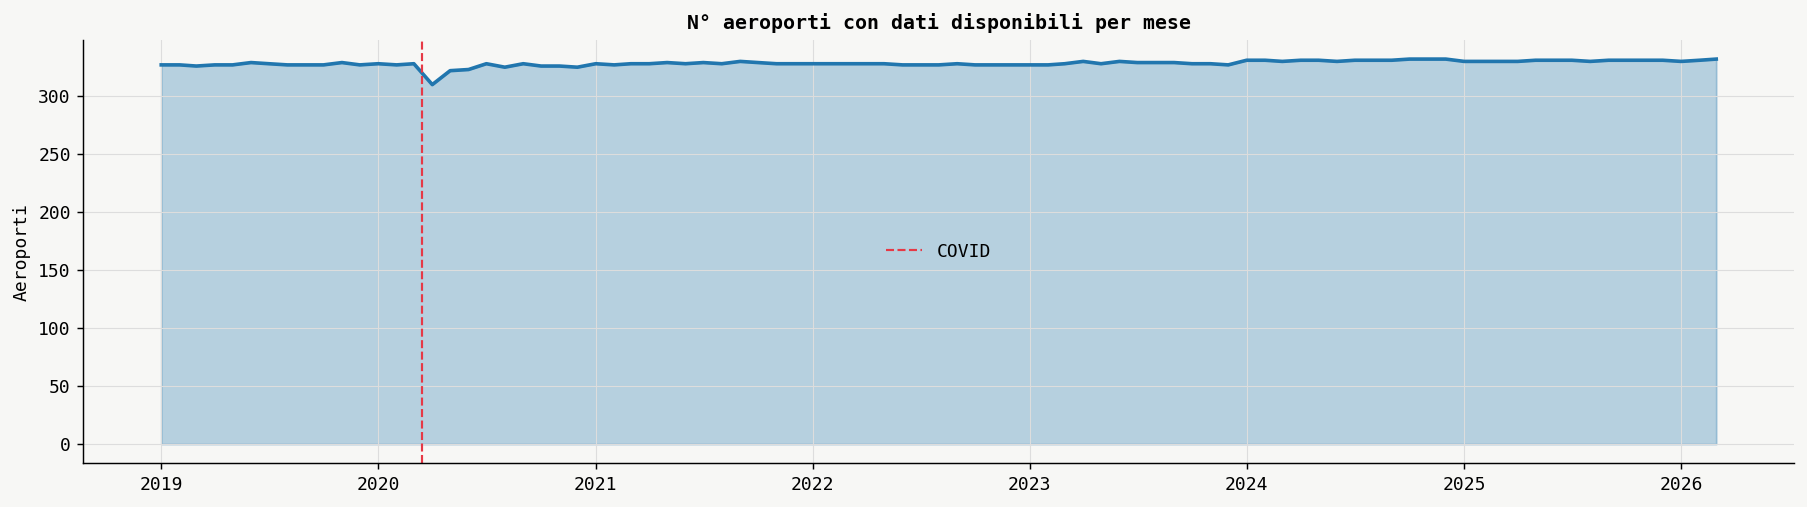

[Salvato] eda_apt_01_coverage.png


In [10]:
# =============================================================================
# 3. COPERTURA: n° aeroporti attivi per mese
# =============================================================================
cov = (
    df.groupby([df["FLT_DATE"].dt.to_period("M")])["APT_ICAO"]
    .nunique()
    .reset_index()
)
cov.columns = ["period", "n_airports"]
cov["date"] = cov["period"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(cov["date"], cov["n_airports"], alpha=0.3, color="#2176AE")
ax.plot(cov["date"], cov["n_airports"], color="#2176AE", lw=2)
ax.axvline(pd.Timestamp("2020-03-15"), color="#E63946", ls="--", lw=1.2, label="COVID")
ax.set_title("N° aeroporti con dati disponibili per mese", fontweight="bold")
ax.set_ylabel("Aeroporti")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_apt_01_coverage.png")
plt.show()
print("[Salvato] eda_apt_01_coverage.png")

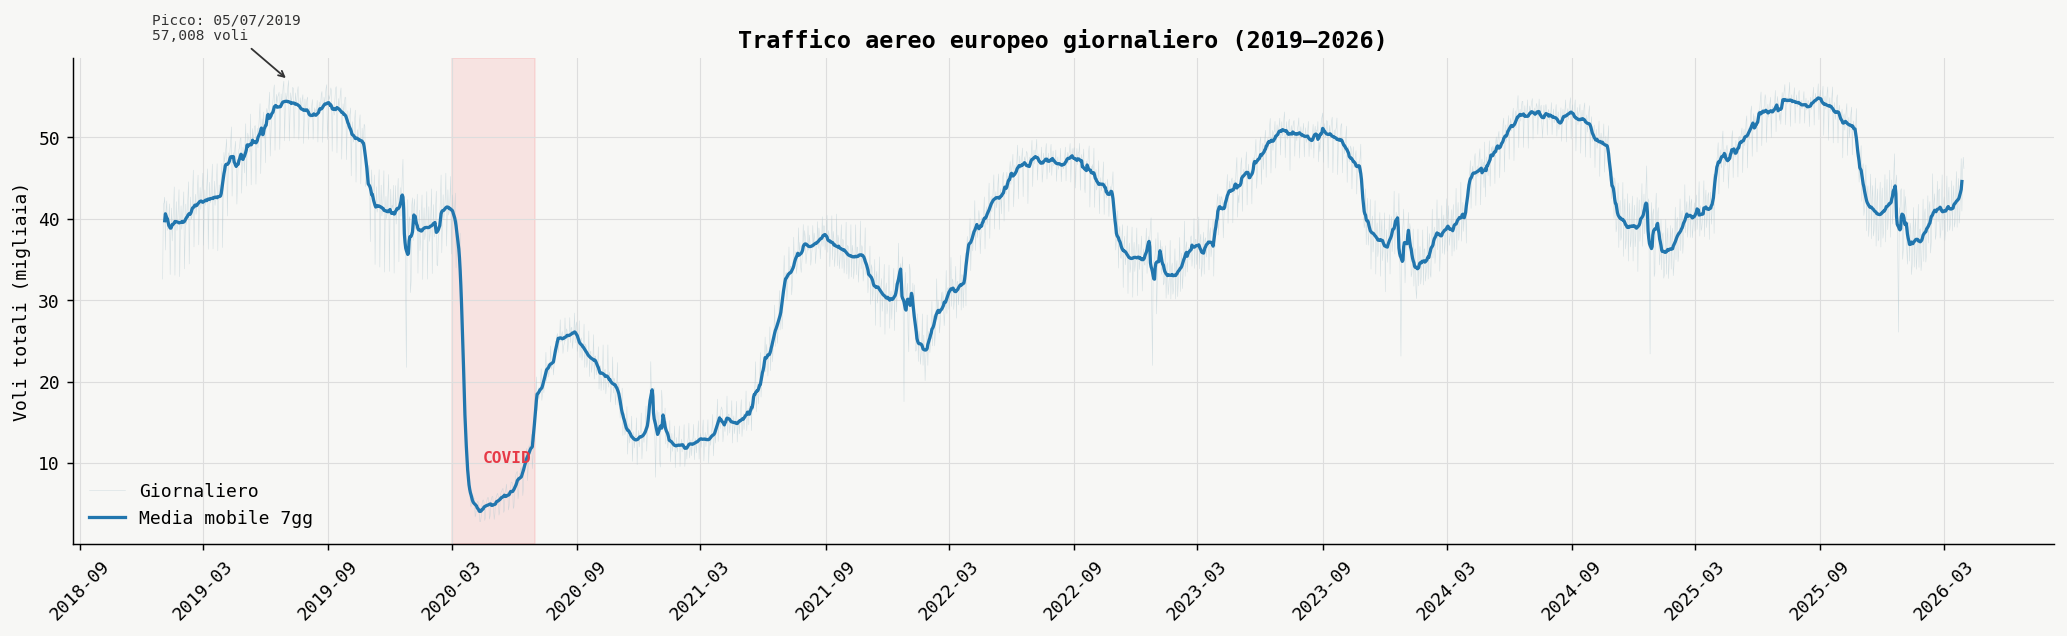

[Salvato] eda_apt_02_daily_trend.png


In [11]:
# =============================================================================
# 4. TREND GIORNALIERO AGGREGATO EUROPA
# =============================================================================
daily = df.groupby("FLT_DATE")["FLT_TOT_1"].sum().reset_index()
daily = daily.sort_values("FLT_DATE")
daily["rolling7"] = daily["FLT_TOT_1"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["FLT_DATE"], daily["FLT_TOT_1"] / 1e3,
        color="#AEC6CF", lw=0.3, alpha=0.5, label="Giornaliero")
ax.plot(daily["FLT_DATE"], daily["rolling7"] / 1e3,
        color="#2176AE", lw=1.8, label="Media mobile 7gg")

# Annotazioni
ax.axvspan("2020-03-01","2020-07-01", alpha=0.08, color="red")
ax.annotate("COVID", xy=(pd.Timestamp("2020-04-15"), 10), fontsize=9,
            color="#E63946", fontweight="bold")

# Trova picco
peak_idx = daily["FLT_TOT_1"].idxmax()
peak_date = daily.loc[peak_idx, "FLT_DATE"]
peak_val  = daily.loc[peak_idx, "FLT_TOT_1"]
ax.annotate(f"Picco: {peak_date.strftime('%d/%m/%Y')}\n{peak_val:,.0f} voli",
            xy=(peak_date, peak_val/1e3),
            xytext=(peak_date - pd.Timedelta(days=200), peak_val/1e3 + 5),
            fontsize=8, arrowprops=dict(arrowstyle="->", color="#333"),
            color="#333")

ax.set_ylabel("Voli totali (migliaia)")
ax.set_title("Traffico aereo europeo giornaliero (2019–2026)", fontweight="bold", fontsize=13)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_apt_02_daily_trend.png")
plt.show()
print("[Salvato] eda_apt_02_daily_trend.png")

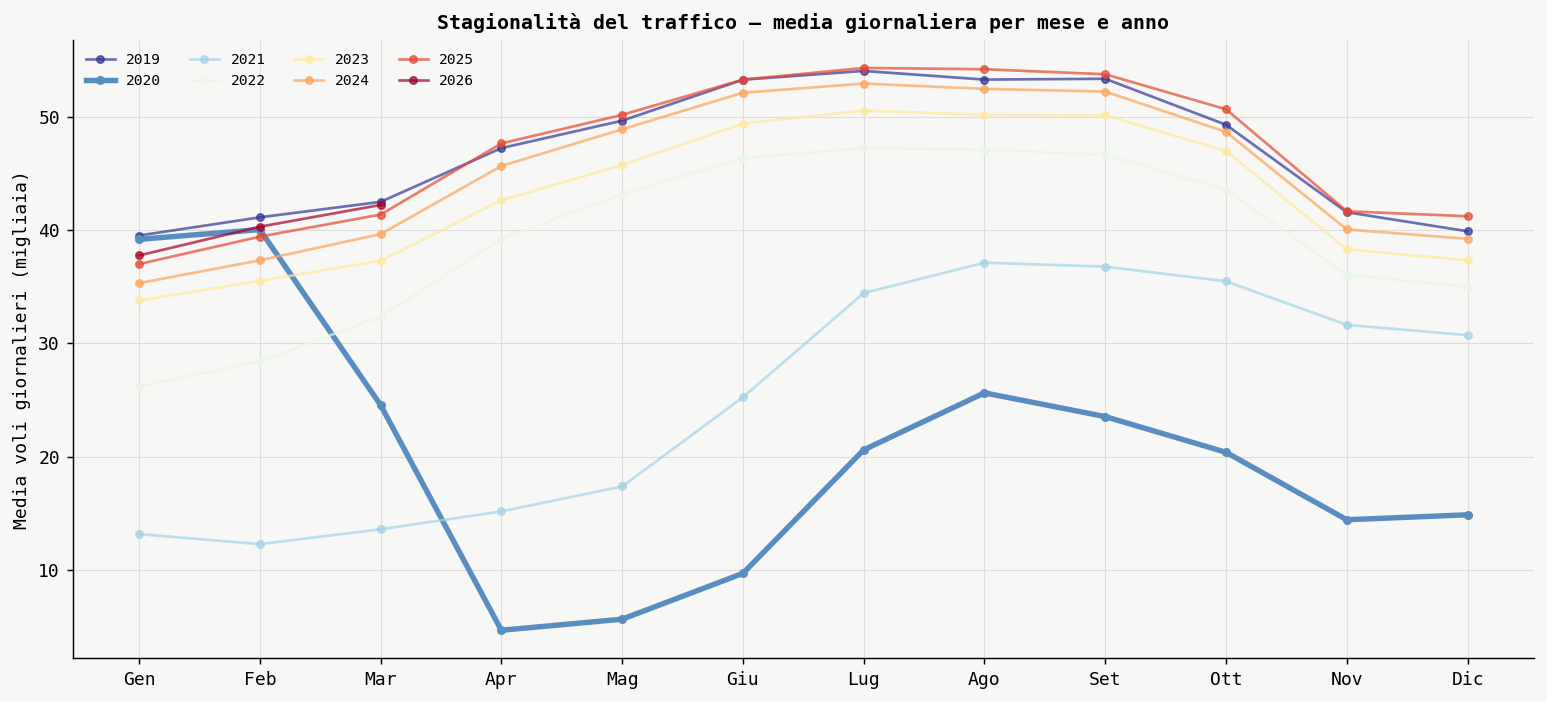

[Salvato] eda_apt_03_seasonality.png


In [12]:
# =============================================================================
# 5. STAGIONALITÀ: media giornaliera per mese (overlay per anno)
# =============================================================================
monthly_avg = (
    df.groupby(["YEAR","MONTH_NUM"])["FLT_TOT_1"].sum()
    .reset_index()
)
# Normalizza per n° giorni nel mese
days_in_month = df.groupby(["YEAR","MONTH_NUM"])["FLT_DATE"].nunique().reset_index()
days_in_month.columns = ["YEAR","MONTH_NUM","n_days"]
monthly_avg = monthly_avg.merge(days_in_month)
monthly_avg["daily_avg"] = monthly_avg["FLT_TOT_1"] / monthly_avg["n_days"]

piv_s = monthly_avg.pivot(index="MONTH_NUM", columns="YEAR", values="daily_avg")

fig, ax = plt.subplots(figsize=(12, 5.5))
palette_yr = cm.get_cmap("RdYlBu_r", len(piv_s.columns))
for i, yr in enumerate(piv_s.columns):
    style = {"lw": 3, "alpha": 1.0} if yr == 2020 else {"lw": 1.5, "alpha": 0.7}
    ax.plot(piv_s.index, piv_s[yr] / 1e3, marker="o", ms=4,
            color=palette_yr(i), label=str(yr), **style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Gen","Feb","Mar","Apr","Mag","Giu",
                     "Lug","Ago","Set","Ott","Nov","Dic"])
ax.set_ylabel("Media voli giornalieri (migliaia)")
ax.set_title("Stagionalità del traffico — media giornaliera per mese e anno",
             fontweight="bold")
ax.legend(ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("eda_apt_03_seasonality.png")
plt.show()
print("[Salvato] eda_apt_03_seasonality.png")

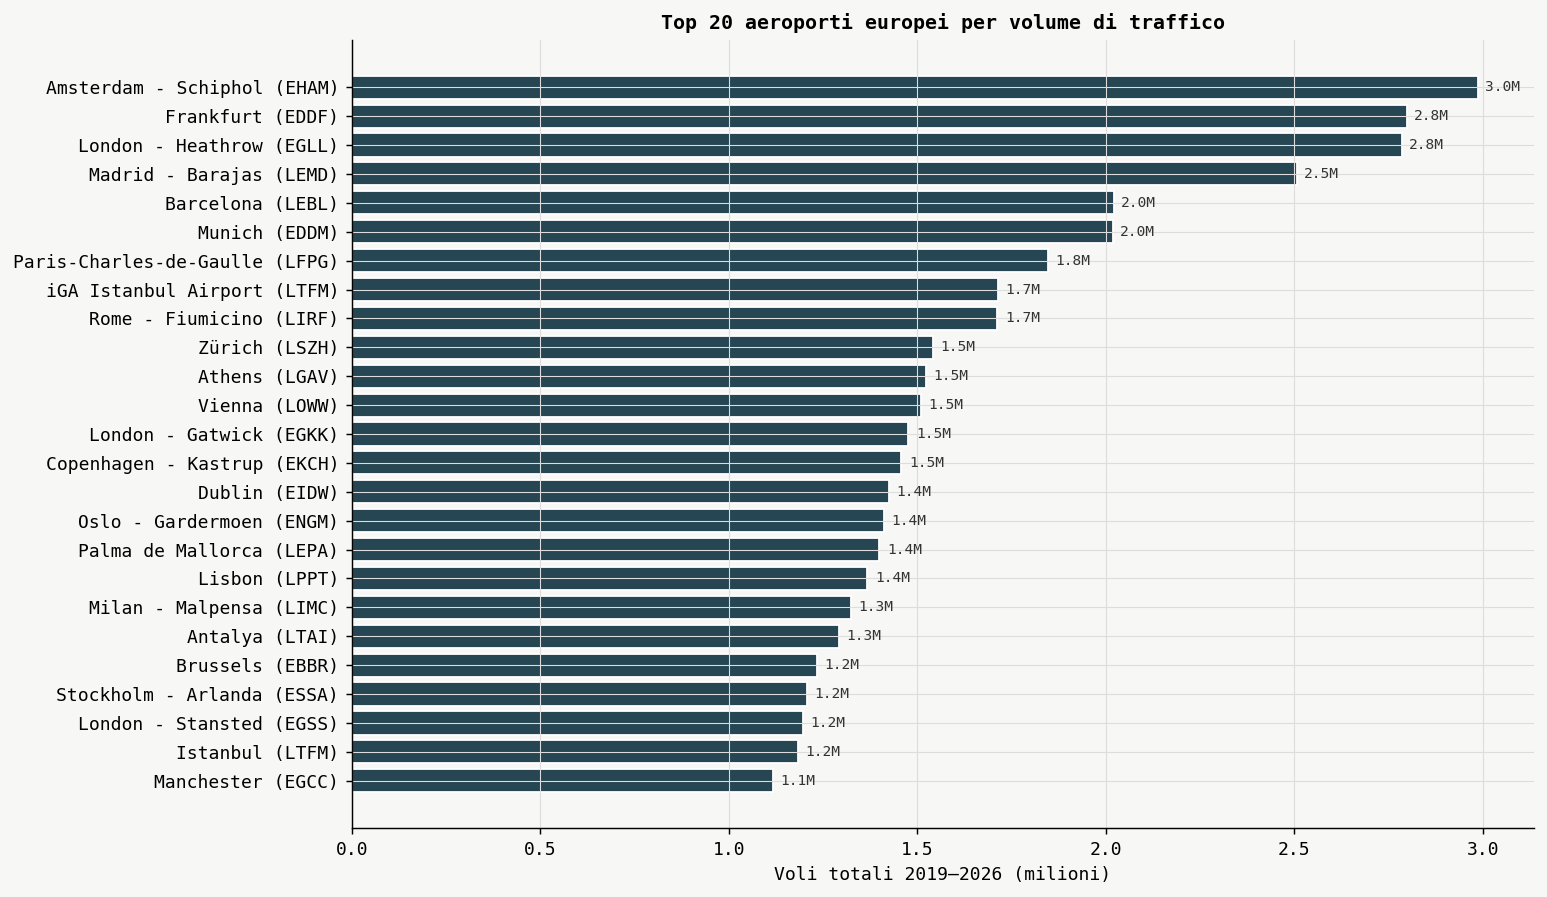

[Salvato] eda_apt_04_top20.png


In [21]:
# =============================================================================
# 6. TOP 20 AEROPORTI (totale voli 2019–2025)
# =============================================================================
top20 = (
    df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{row.APT_NAME} ({row.APT_ICAO})" for _, row in top20.iterrows()]
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Voli totali 2019–2026 (milioni)")
ax.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#333")

plt.tight_layout()
plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

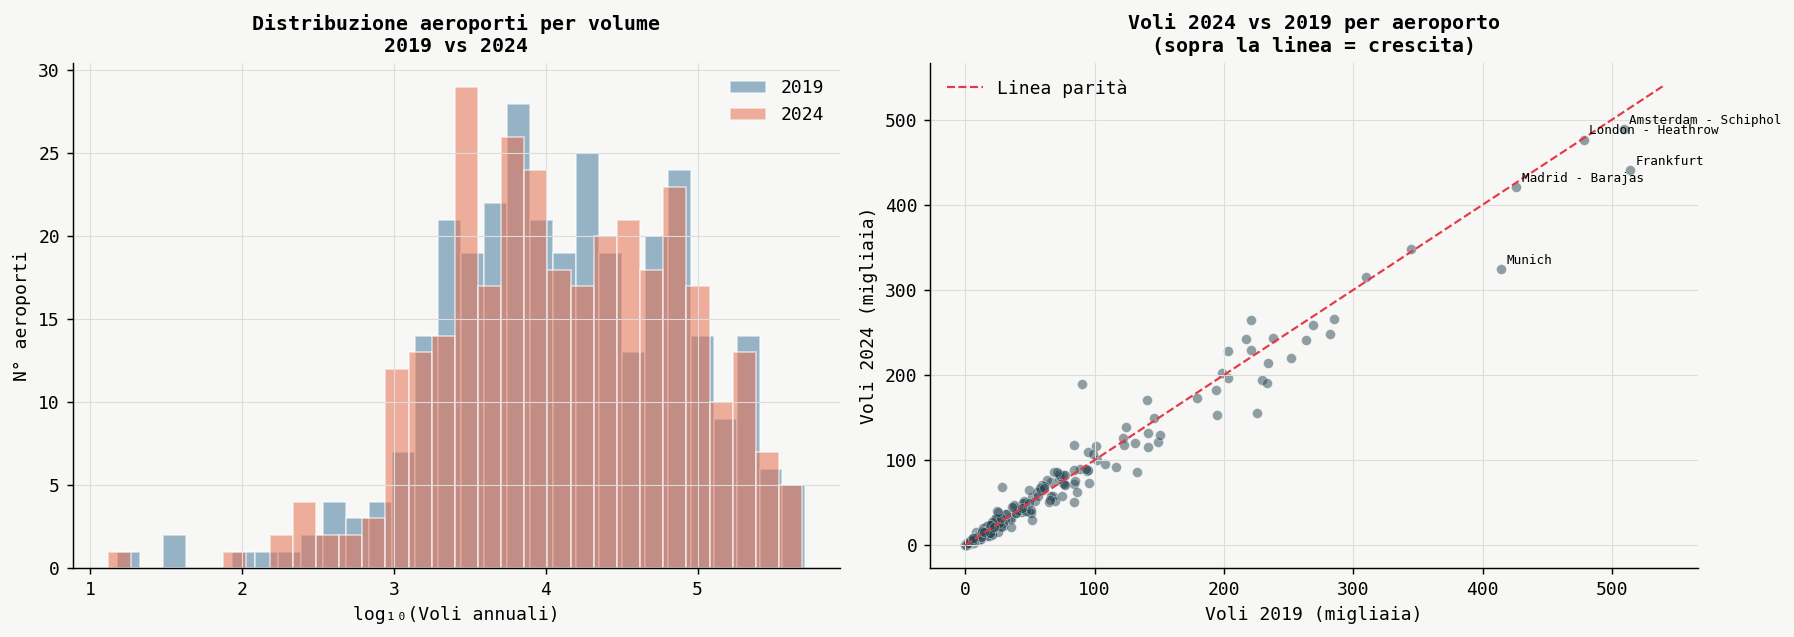

[Salvato] eda_apt_05_distribution.png


In [14]:
# =============================================================================
# 7. DISTRIBUZIONE DIMENSIONALE: 2019 vs 2024
# =============================================================================
apt_year = df[df["YEAR"].isin([2019,2024])].groupby(
    ["APT_ICAO","APT_NAME","YEAR"]
)["FLT_TOT_1"].sum().reset_index()

apt_piv = apt_year.pivot(index=["APT_ICAO","APT_NAME"],
                          columns="YEAR", values="FLT_TOT_1").dropna()
apt_piv = apt_piv.rename(columns={2019:"y2019", 2024:"y2024"})
apt_piv["log2019"] = np.log10(apt_piv["y2019"].clip(lower=1))
apt_piv["log2024"] = np.log10(apt_piv["y2024"].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogrammi sovrapposti
for label, col, color in [("2019","log2019","#457B9D"),("2024","log2024","#E76F51")]:
    axes[0].hist(apt_piv[col], bins=30, alpha=0.55, color=color, label=label, edgecolor="white")
axes[0].set_xlabel("log₁₀(Voli annuali)")
axes[0].set_ylabel("N° aeroporti")
axes[0].set_title("Distribuzione aeroporti per volume\n2019 vs 2024", fontweight="bold")
axes[0].legend(frameon=False)

# Scatter 2019 vs 2024
axes[1].scatter(apt_piv["y2019"]/1e3, apt_piv["y2024"]/1e3,
                s=30, alpha=0.5, color="#264653", edgecolors="white", lw=0.3)
maxval = max(apt_piv["y2019"].max(), apt_piv["y2024"].max()) / 1e3 * 1.05
axes[1].plot([0, maxval], [0, maxval], color="#E63946", ls="--", lw=1.2,
             label="Linea parità")
axes[1].set_xlabel("Voli 2019 (migliaia)")
axes[1].set_ylabel("Voli 2024 (migliaia)")
axes[1].set_title("Voli 2024 vs 2019 per aeroporto\n(sopra la linea = crescita)", fontweight="bold")
axes[1].legend(frameon=False)

# Etichette outlier
apt_piv_reset = apt_piv.reset_index()
for _, r in apt_piv_reset.nlargest(5, "y2019").iterrows():
    axes[1].annotate(r["APT_NAME"], xy=(r["y2019"]/1e3, r["y2024"]/1e3),
                     fontsize=7, ha="left", xytext=(3,3), textcoords="offset points")

plt.tight_layout()
plt.savefig("eda_apt_05_distribution.png")
plt.show()
print("[Salvato] eda_apt_05_distribution.png")

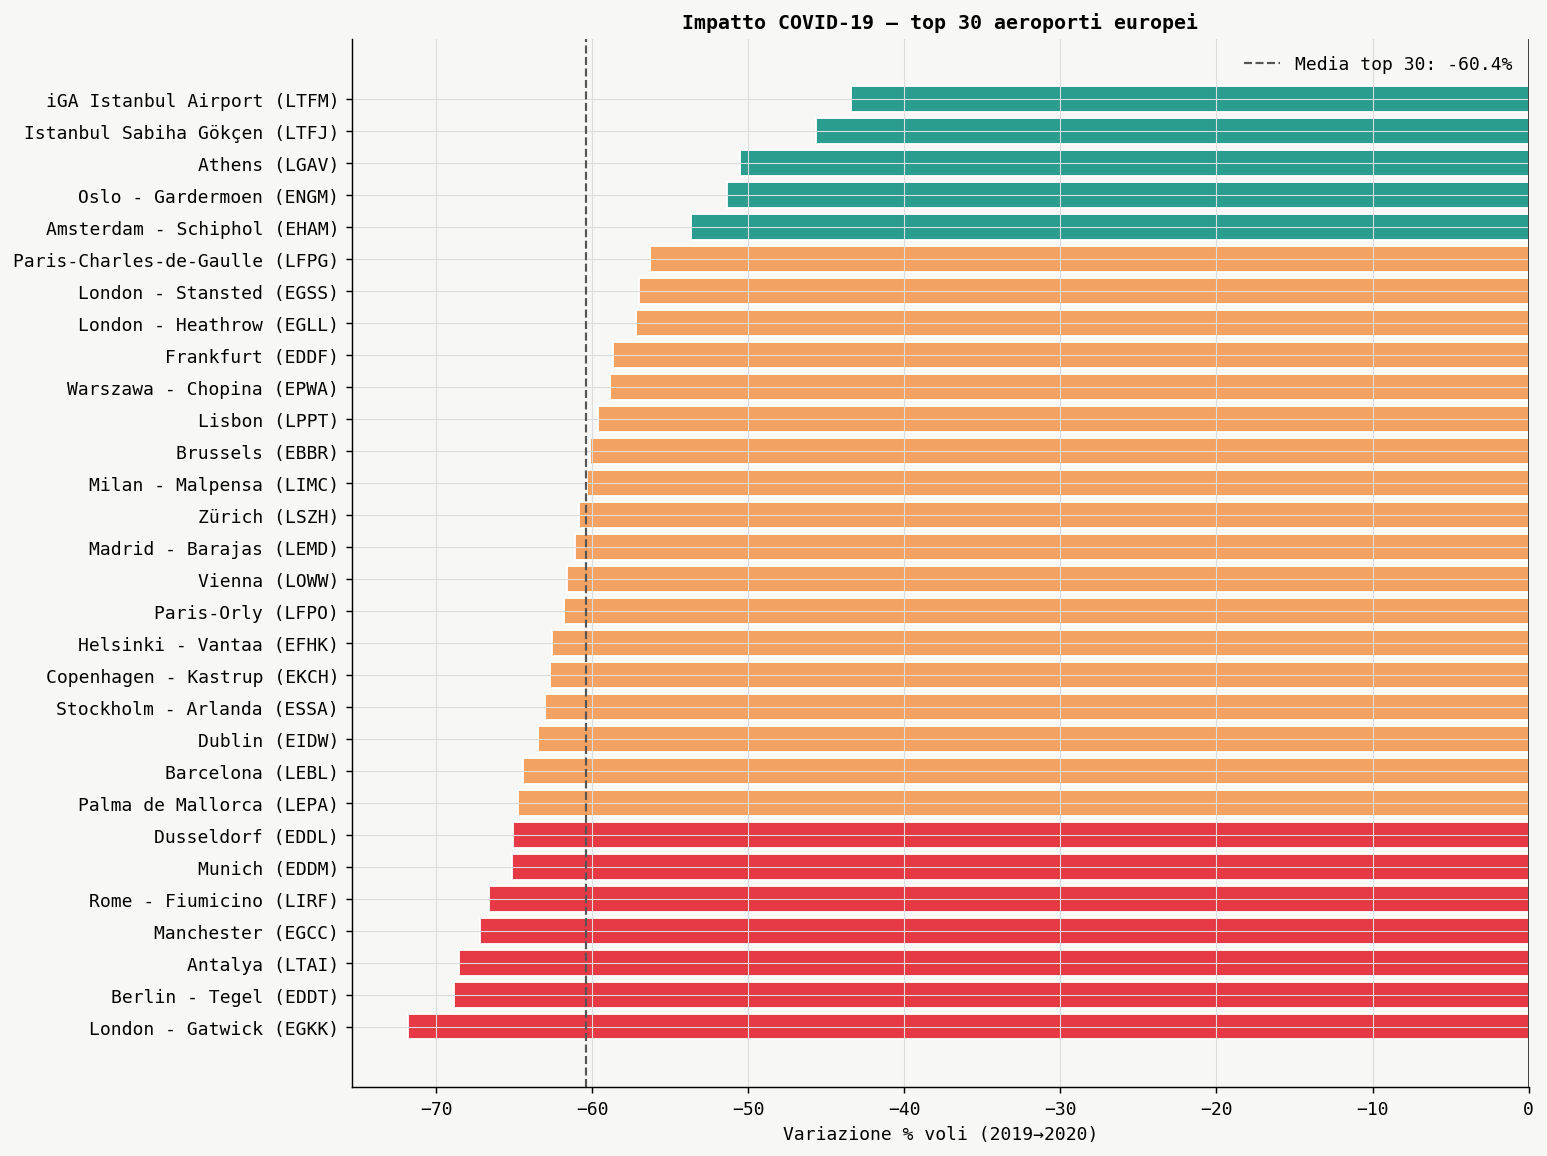

[Salvato] eda_apt_06_covid.png


In [15]:
# =============================================================================
# 8. IMPATTO COVID: top 30 aeroporti, calo 2019→2020
# =============================================================================
apt_covid_raw = df[df["YEAR"].isin([2019,2020])].groupby(
    ["APT_ICAO","APT_NAME","YEAR"]
)["FLT_TOT_1"].sum().reset_index()
apt_covid = apt_covid_raw.pivot(index=["APT_ICAO","APT_NAME"], columns="YEAR", values="FLT_TOT_1").dropna()
apt_covid = apt_covid.rename(columns={2019:"y2019", 2020:"y2020"})
apt_covid["drop_pct"] = (apt_covid["y2020"] - apt_covid["y2019"]) / apt_covid["y2019"] * 100

# Solo top 30 per volume 2019
apt_covid_top = apt_covid.nlargest(30, "y2019").sort_values("drop_pct")
names = [f"{n} ({c})" for (c, n) in apt_covid_top.index]

fig, ax = plt.subplots(figsize=(12, 9))
colors_bar = ["#E63946" if v < -65 else "#F4A261" if v < -55 else "#2A9D8F"
              for v in apt_covid_top["drop_pct"]]
ax.barh(names, apt_covid_top["drop_pct"], color=colors_bar, edgecolor="white")
ax.axvline(0, color="#333", lw=1)
avg = apt_covid_top["drop_pct"].mean()
ax.axvline(avg, color="#555", ls="--", lw=1.2,
           label=f"Media top 30: {avg:.1f}%")
ax.set_xlabel("Variazione % voli (2019→2020)")
ax.set_title("Impatto COVID-19 — top 30 aeroporti europei", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_apt_06_covid.png")
plt.show()
print("[Salvato] eda_apt_06_covid.png")

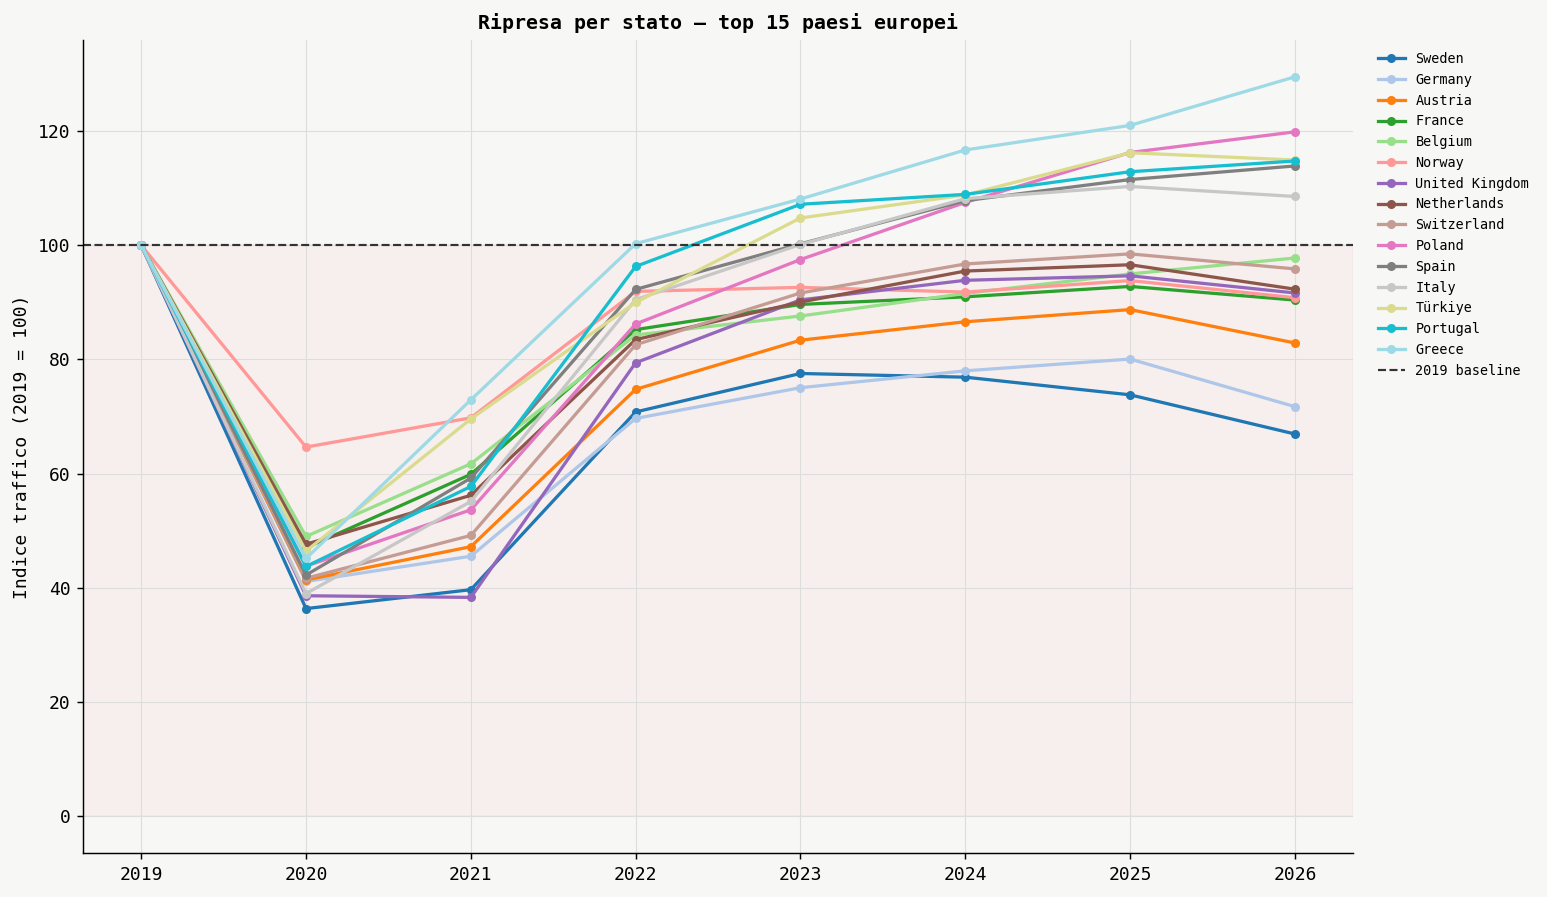

[Salvato] eda_apt_07_state_recovery.png


In [16]:
# =============================================================================
# 9. RIPRESA PER STATO: indice voli mensili (2019=100)
# =============================================================================
state_monthly = (
    df.groupby(["STATE_NAME","YEAR","MONTH_NUM"])["FLT_TOT_1"].sum()
    .reset_index()
)
# Baseline 2019 per stato/mese
base_2019 = (
    state_monthly[state_monthly["YEAR"] == 2019]
    .rename(columns={"FLT_TOT_1":"base_2019"})
    [["STATE_NAME","MONTH_NUM","base_2019"]]
)
state_monthly = state_monthly.merge(base_2019, on=["STATE_NAME","MONTH_NUM"], how="left")
state_monthly["index_100"] = state_monthly["FLT_TOT_1"] / state_monthly["base_2019"] * 100

# Annuale per stato
state_annual_idx = (
    state_monthly.groupby(["STATE_NAME","YEAR"])
    .agg(tot=("FLT_TOT_1","sum"), base=("base_2019","sum"))
    .reset_index()
)
state_annual_idx["idx"] = state_annual_idx["tot"] / state_annual_idx["base"] * 100

# Top 15 stati per traffico
top15_states = (
    df[df["YEAR"]==2019].groupby("STATE_NAME")["FLT_TOT_1"].sum()
    .nlargest(15).index.tolist()
)

piv_rec = state_annual_idx[state_annual_idx["STATE_NAME"].isin(top15_states)].pivot(
    index="STATE_NAME", columns="YEAR", values="idx"
)
# Ordina per valore 2024
piv_rec = piv_rec.sort_values(2024, ascending=True) if 2024 in piv_rec.columns else piv_rec

fig, ax = plt.subplots(figsize=(12, 7))
palette_st = cm.get_cmap("tab20", len(piv_rec))
for i, state in enumerate(piv_rec.index):
    row = piv_rec.loc[state].dropna()
    ax.plot(row.index, row.values, marker="o", ms=4,
            color=palette_st(i), lw=1.8, label=state)

ax.axhline(100, color="#333", ls="--", lw=1.2, label="2019 baseline")
ax.axhspan(0, 100, alpha=0.04, color="#E63946")
ax.set_ylabel("Indice traffico (2019 = 100)")
ax.set_title("Ripresa per stato — top 15 paesi europei", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7.5, frameon=False)
plt.tight_layout()
plt.savefig("eda_apt_07_state_recovery.png")
plt.show()
print("[Salvato] eda_apt_07_state_recovery.png")

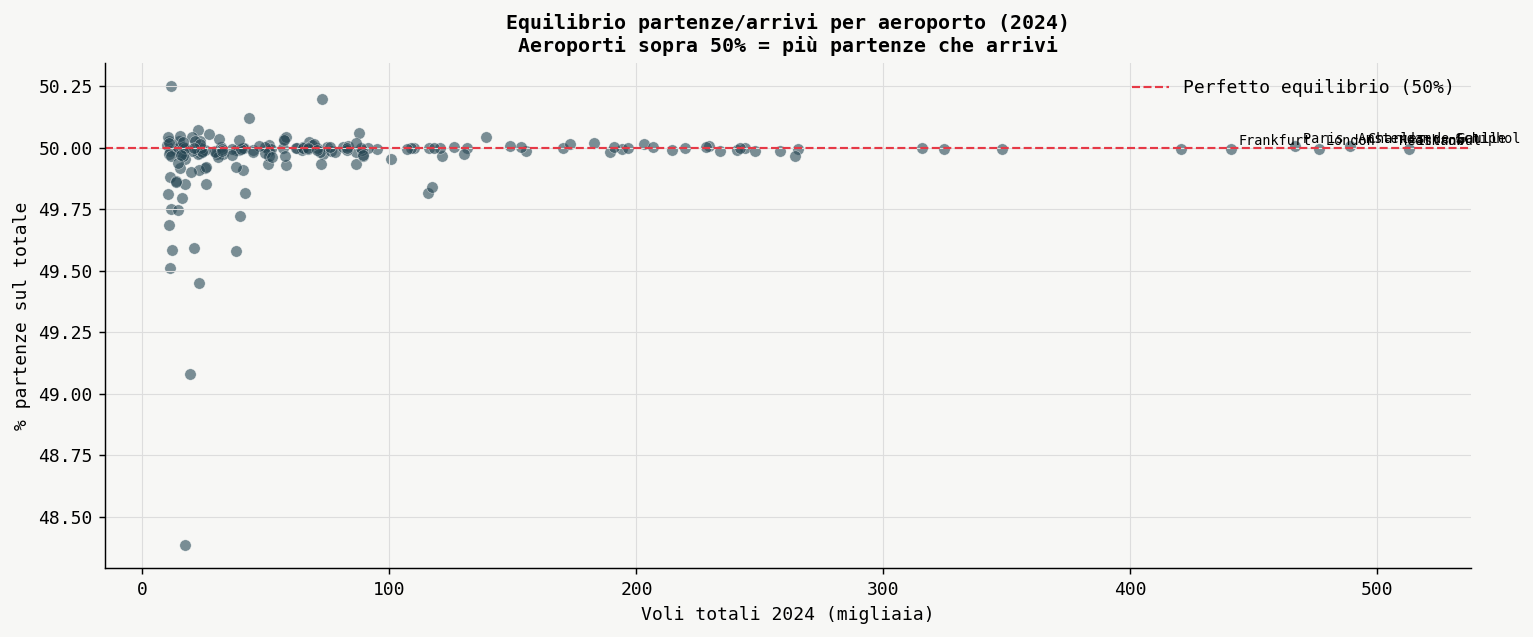

[Salvato] eda_apt_08_dep_arr_ratio.png


In [17]:
# =============================================================================
# 10. ASIMMETRIA PARTENZE/ARRIVI (hub analysis)
# =============================================================================
apt_ratio = (
    df[df["YEAR"] == 2024]
    .groupby(["APT_ICAO","APT_NAME"])[["FLT_DEP_1","FLT_ARR_1","FLT_TOT_1"]]
    .sum()
    .reset_index()
)
apt_ratio["dep_share"] = apt_ratio["FLT_DEP_1"] / apt_ratio["FLT_TOT_1"] * 100
apt_ratio = apt_ratio[apt_ratio["FLT_TOT_1"] >= 10000]  # aeroporti significativi

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(apt_ratio["FLT_TOT_1"] / 1e3,
                apt_ratio["dep_share"],
                s=40, alpha=0.6, c="#264653", edgecolors="white", lw=0.3)
ax.axhline(50, color="#E63946", ls="--", lw=1.2, label="Perfetto equilibrio (50%)")
ax.set_xlabel("Voli totali 2024 (migliaia)")
ax.set_ylabel("% partenze sul totale")
ax.set_title("Equilibrio partenze/arrivi per aeroporto (2024)\n"
             "Aeroporti sopra 50% = più partenze che arrivi", fontweight="bold")
ax.legend(frameon=False)

# Etichette estremi
extremes = apt_ratio.nlargest(5, "FLT_TOT_1")
for _, r in extremes.iterrows():
    ax.annotate(r["APT_NAME"], xy=(r["FLT_TOT_1"]/1e3, r["dep_share"]),
                fontsize=7.5, ha="left", xytext=(4,2), textcoords="offset points")

plt.tight_layout()
plt.savefig("eda_apt_08_dep_arr_ratio.png")
plt.show()
print("[Salvato] eda_apt_08_dep_arr_ratio.png")

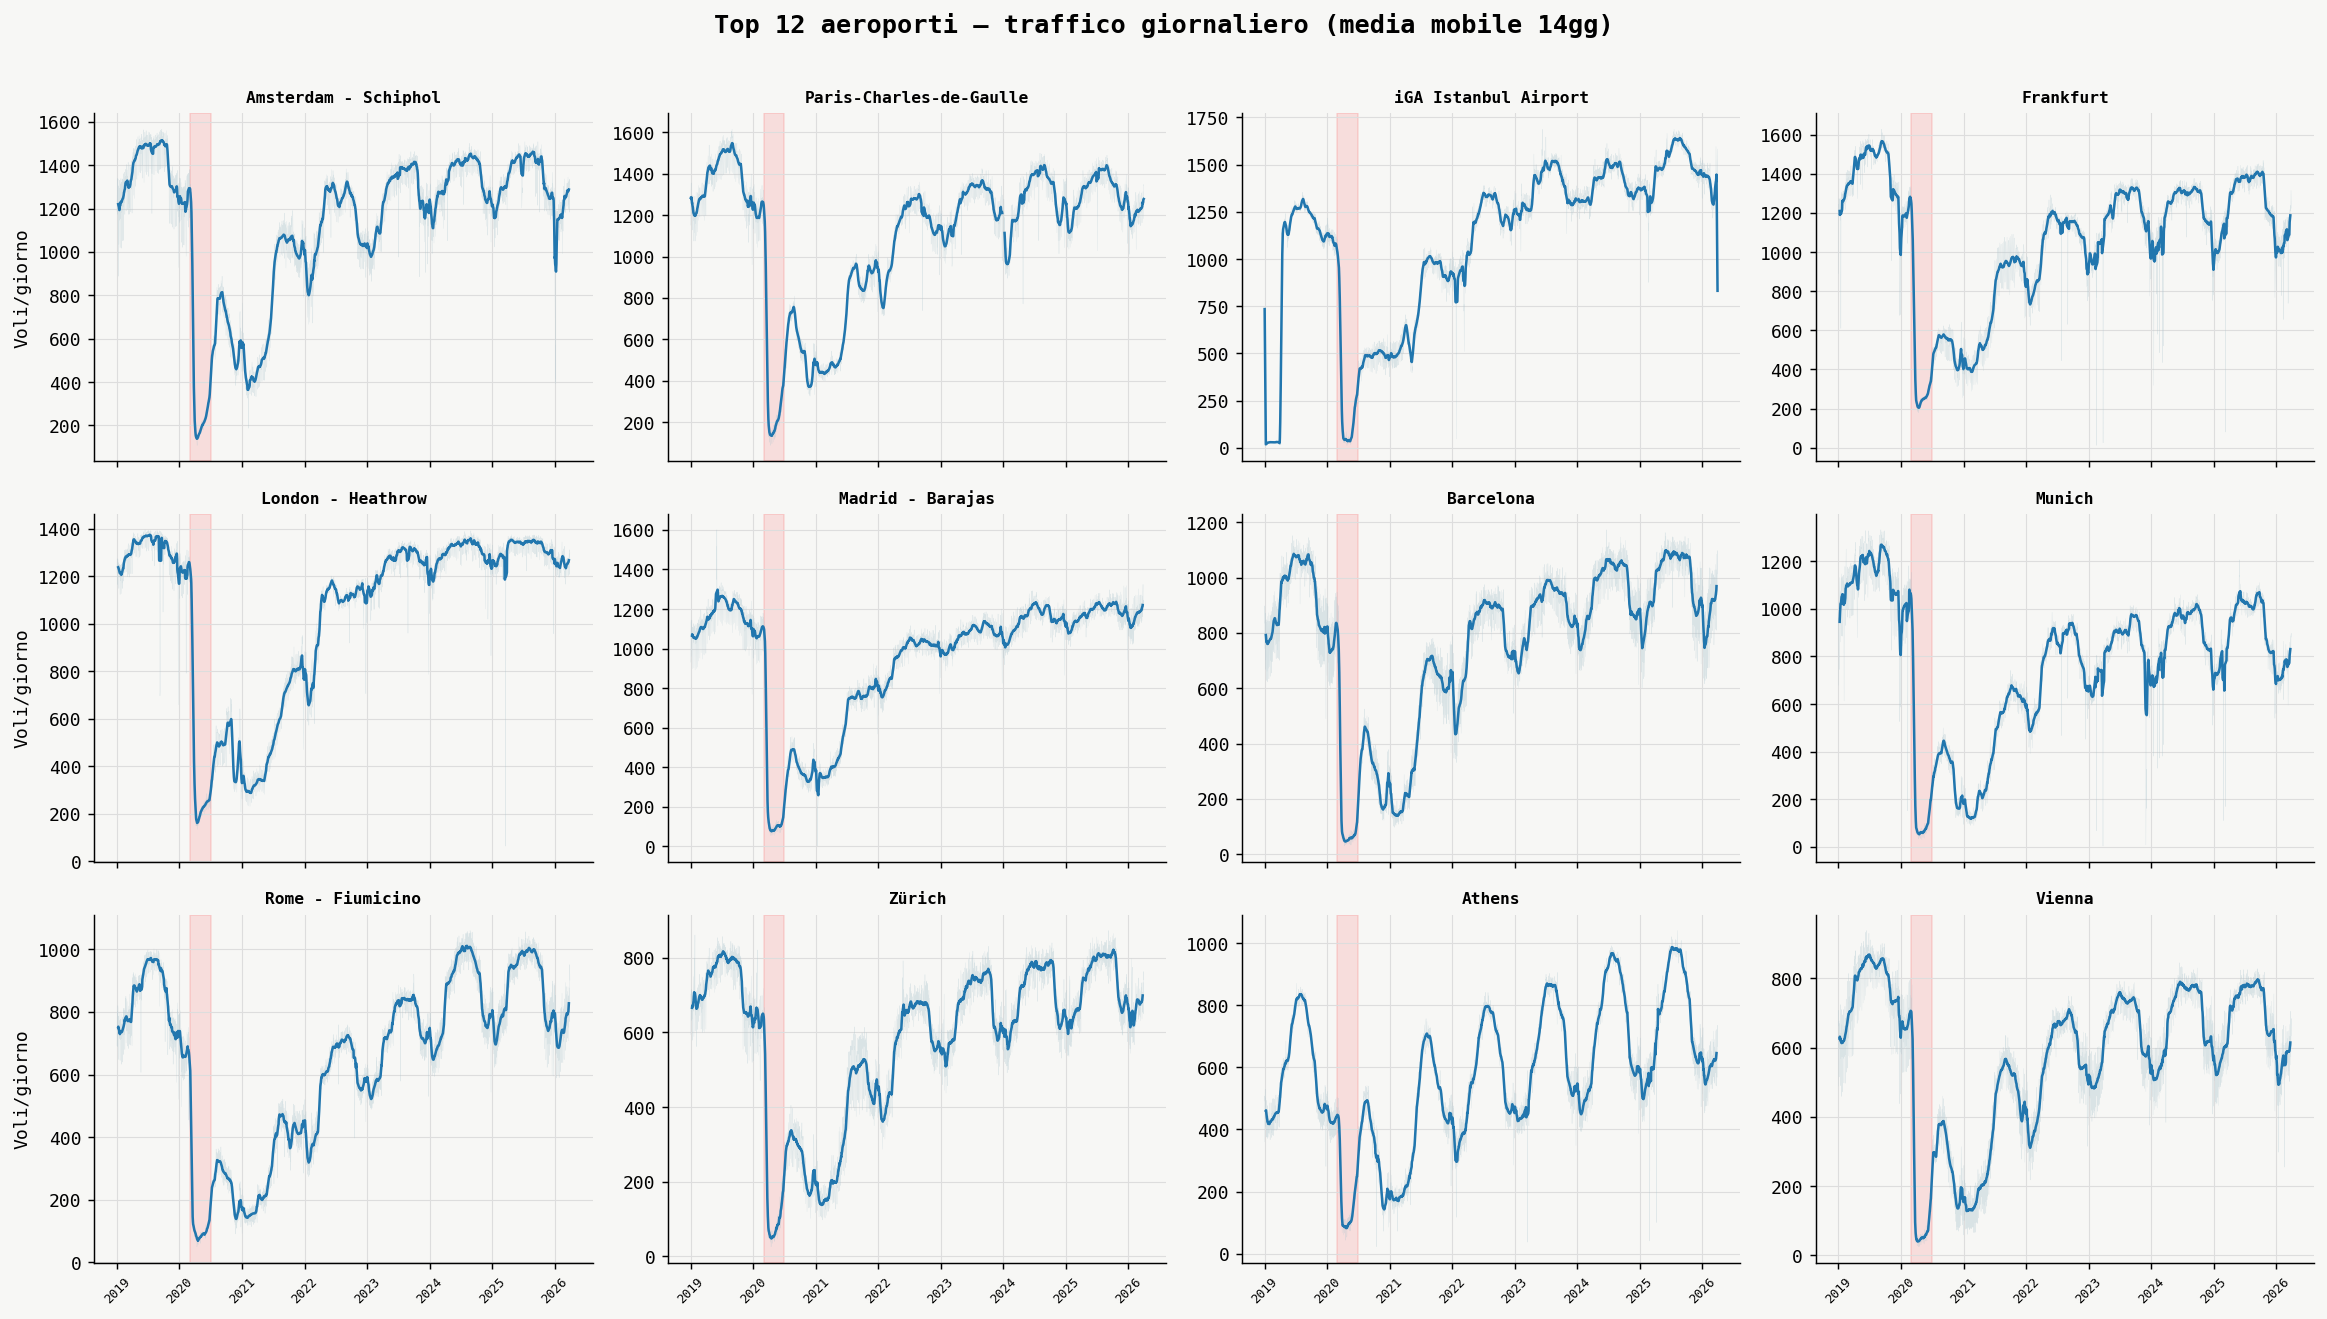

[Salvato] eda_apt_09_small_multiples.png


In [18]:
# =============================================================================
# 11. SMALL MULTIPLES: top 12 aeroporti
# =============================================================================
top12_codes = (
    df.groupby("APT_ICAO")["FLT_TOT_1"].sum()
    .nlargest(12).index.tolist()
)
sm = df[df["APT_ICAO"].isin(top12_codes)].copy()
sm_daily = sm.groupby(["APT_ICAO","APT_NAME","FLT_DATE"])["FLT_TOT_1"].sum().reset_index()
sm_daily["rolling"] = (
    sm_daily.groupby("APT_ICAO")["FLT_TOT_1"]
    .transform(lambda s: s.rolling(14, center=True).mean())
)

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True)
axes_flat = axes.flatten()

for i, code in enumerate(top12_codes):
    ax = axes_flat[i]
    sub = sm_daily[sm_daily["APT_ICAO"] == code].sort_values("FLT_DATE")
    name = sub["APT_NAME"].iloc[0]
    ax.plot(sub["FLT_DATE"], sub["FLT_TOT_1"],
            color="#AEC6CF", lw=0.2, alpha=0.4)
    ax.plot(sub["FLT_DATE"], sub["rolling"],
            color="#2176AE", lw=1.4)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-07-01"),
               alpha=0.1, color="red")
    ax.set_title(f"{name}", fontweight="bold", fontsize=9)
    if i % 4 == 0:
        ax.set_ylabel("Voli/giorno")

for ax in axes_flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Top 12 aeroporti — traffico giornaliero (media mobile 14gg)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_apt_09_small_multiples.png")
plt.show()
print("[Salvato] eda_apt_09_small_multiples.png")


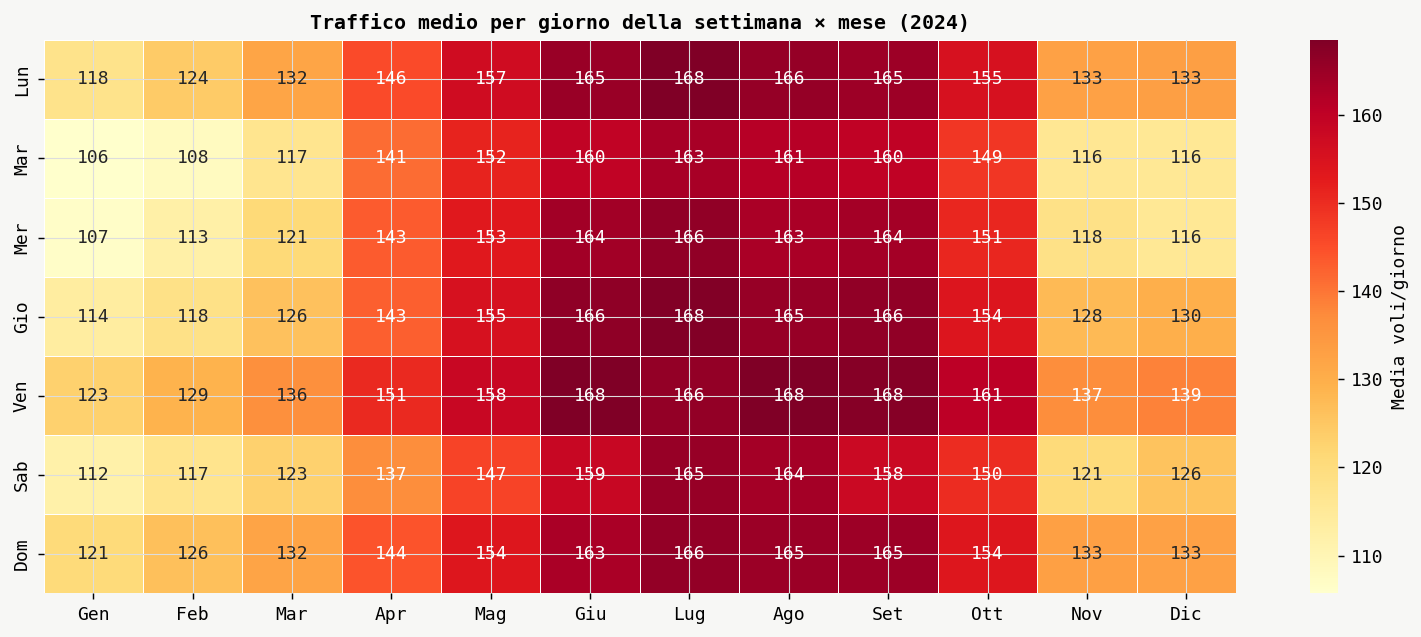

[Salvato] eda_apt_10_heatmap_dow.png


In [19]:
# =============================================================================
# 12. HEATMAP: giorno della settimana × mese (2024)
# =============================================================================
hw = df[df["YEAR"] == 2024].copy()
hw_agg = hw.groupby(["DOW","MONTH_NUM"])["FLT_TOT_1"].mean().reset_index()
hw_piv = hw_agg.pivot(index="DOW", columns="MONTH_NUM", values="FLT_TOT_1")

dow_labels = ["Lun","Mar","Mer","Gio","Ven","Sab","Dom"]
mon_labels = ["Gen","Feb","Mar","Apr","Mag","Giu",
              "Lug","Ago","Set","Ott","Nov","Dic"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(hw_piv, annot=True, fmt=",.0f", cmap="YlOrRd",
            xticklabels=mon_labels, yticklabels=dow_labels,
            ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Media voli/giorno"})
ax.set_title("Traffico medio per giorno della settimana × mese (2024)",
             fontweight="bold")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("eda_apt_10_heatmap_dow.png")
plt.show()
print("[Salvato] eda_apt_10_heatmap_dow.png")

In [20]:
# =============================================================================
# 13. RIEPILOGO
# =============================================================================
print("\n" + "="*60)
print("RIEPILOGO EDA — airport_traffic_merged.csv")
print("="*60)

yearly = df.groupby("YEAR")["FLT_TOT_1"].sum()
print("\nVoli totali per anno:")
for yr, val in yearly.items():
    tag = " ← COVID" if yr == 2020 else ""
    print(f"  {yr}: {val:>14,}{tag}")

print(f"\nAeroporti più trafficati (top 5, tutto il periodo):")
top5 = df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum().nlargest(5)
for (icao, name), val in top5.items():
    print(f"  {icao} {name:<30} {val/1e6:.1f}M voli")

# Recovery 2024 vs 2019
yr_1924 = df[df["YEAR"].isin([2019,2024])].groupby("YEAR")["FLT_TOT_1"].sum()
if 2024 in yr_1924.index:
    rec = yr_1924[2024] / yr_1924[2019] * 100
    print(f"\n  Traffico 2024 vs 2019: {rec:.1f}%")

# Sabato vs venerdì
if len(hw_piv) > 0:
    ven = hw_piv.loc[4].mean()
    sab = hw_piv.loc[5].mean()
    print(f"  Media voli venerdì 2024: {ven:,.0f}")
    print(f"  Media voli sabato 2024:  {sab:,.0f} ({sab/ven*100:.0f}% del venerdì)")


RIEPILOGO EDA — airport_traffic_merged.csv

Voli totali per anno:
  2019:     17,185,911
  2020:      7,417,016 ← COVID
  2021:      9,252,593
  2022:     14,356,972
  2023:     15,764,547
  2024:     16,613,971
  2025:     17,188,114
  2026:      3,607,666

Aeroporti più trafficati (top 5, tutto il periodo):
  EHAM Amsterdam - Schiphol           3.0M voli
  EDDF Frankfurt                      2.8M voli
  EGLL London - Heathrow              2.8M voli
  LEMD Madrid - Barajas               2.5M voli
  LEBL Barcelona                      2.0M voli

  Traffico 2024 vs 2019: 96.7%
  Media voli venerdì 2024: 150
  Media voli sabato 2024:  140 (93% del venerdì)
